# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
# Load the MNase data for a cycling window:

from src.chromatin_model import read_chromosome_mnase_reads
from src.global_config import GlobalConstants

chr_reads = read_chromosome_mnase_reads(chr=16, replicate=1)
mnase_span = (771600, 771900)

locus_reads = chr_reads[(chr_reads.mid > mnase_span[0]) & 
                        (chr_reads.mid < mnase_span[1])]


In [565]:
from src.chromatin_model import create_exact_bins, downsample_bins, normalize_bins_by_len

timepoints = GlobalConstants.CHROM_WT1_TIMEPOINTS
exact_bins = create_exact_bins(locus_reads, mnase_span, timepoints)
normalized_bins = normalize_bins_by_len(1, exact_bins, log=False)


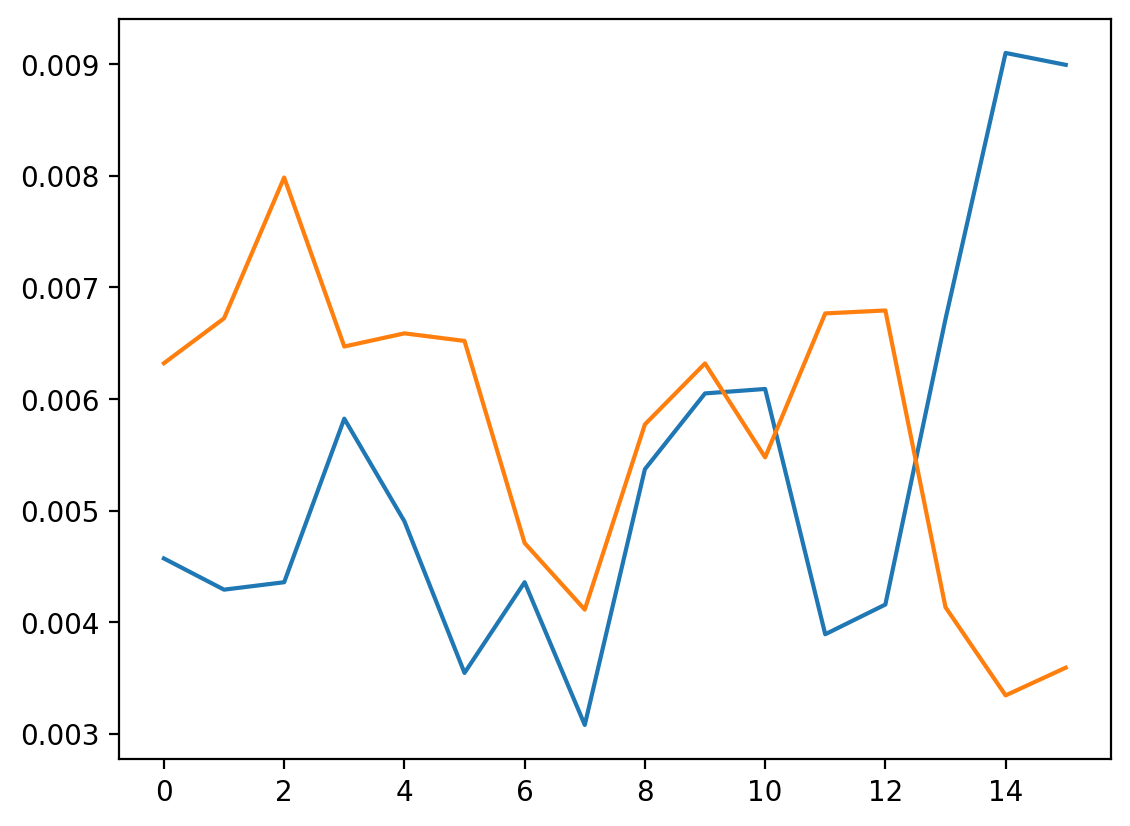

In [566]:
plt.plot(exact_bins.mean(axis=1).mean(axis=1))
plt.plot(normalized_bins.mean(axis=1).mean(axis=1))

In [568]:
downsampled_bins = downsample_bins(normalized_bins, mnase_span, GlobalConstants.BIN_WIDTH, 
    GlobalConstants.BIN_HEIGHT, GlobalConstants.MAX_Y_LEN, timepoints)

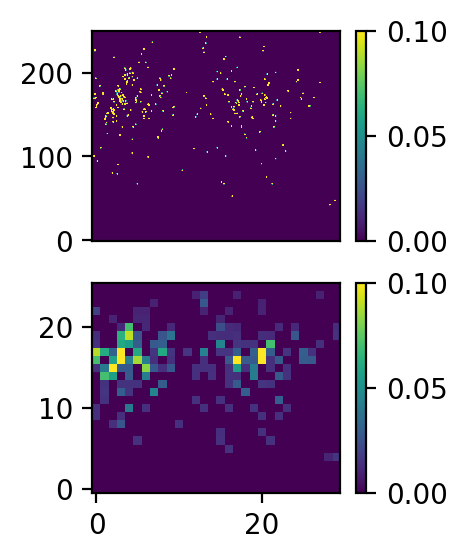

In [569]:
fig = plt.figure(figsize=(2, 3))
plt.subplot(2, 1, 1)
plt.imshow(exact_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()
plt.xticks([])

plt.subplot(2, 1, 2)
plt.imshow(downsampled_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()

In [572]:
from src.deconvolution_solver import DeconvolutionSolver
from src.rg1_refactor import load_default_chrom_configs
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

config, _ = load_default_chrom_configs()
H = config.calculate_H()
gamma = 0.00091
padding_type = 'both'

b = 1
N = np.eye(H.shape[0])
f_replication = np.ones(H.shape[1])

G = downsampled_bins.reshape((downsampled_bins.shape[0], -1))

chromatin_solver = ChromatinDeconvolveSolver(config, H, G, N, b, f_replication)


In [574]:
gamma = 0.00085
F = chromatin_solver.deconvolve_G_iteratively(gamma=gamma)

0/780 - 00:00:00.120
500/780 - 00:00:50.947


Text(0.5, 1.0, 'Predicted and actual G')

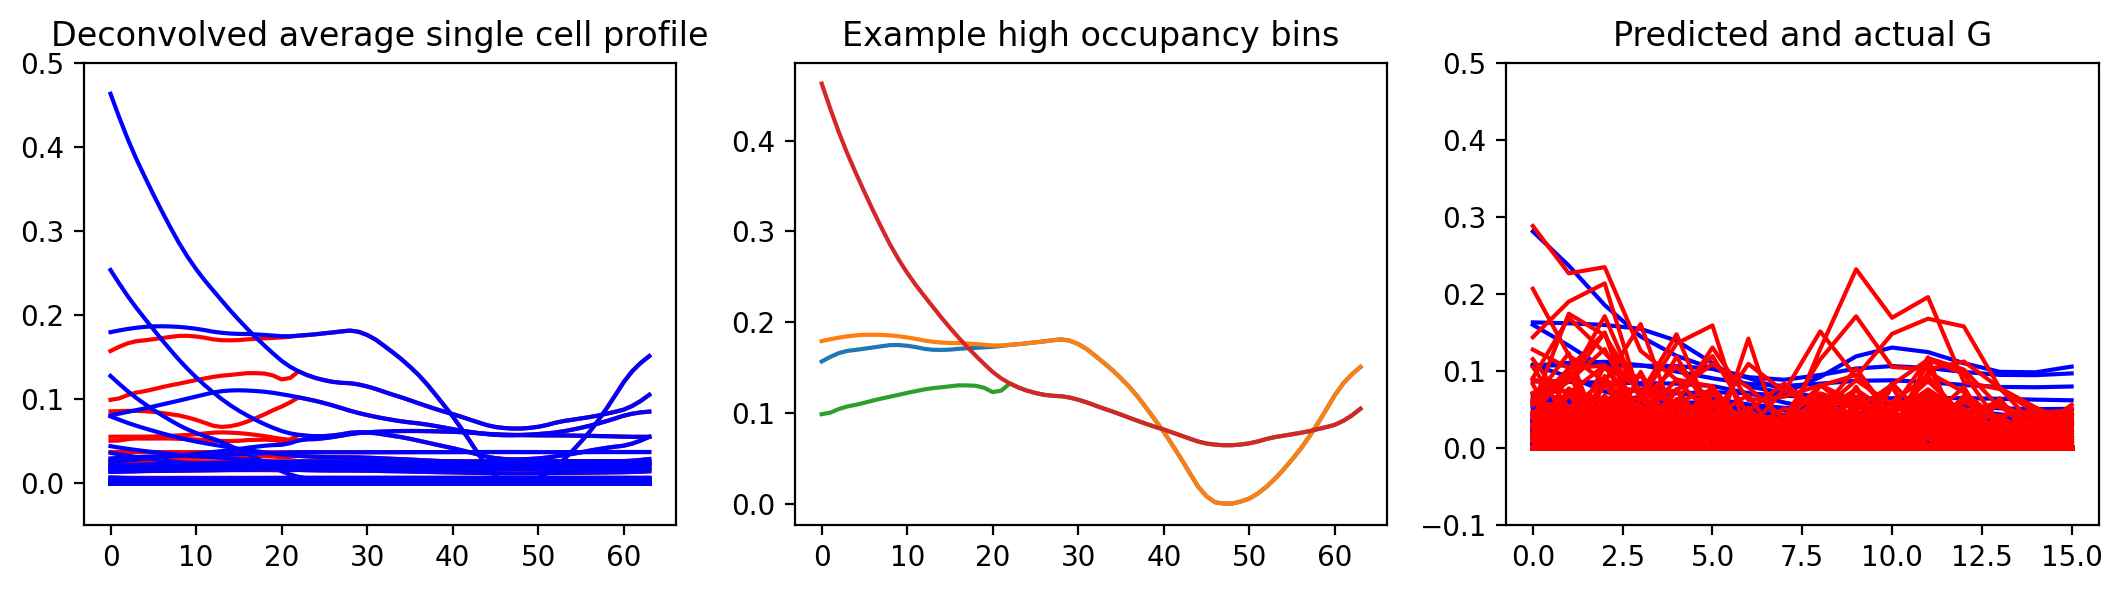

In [624]:
plt.figure(figsize=(13, 3))

plt.subplot(1, 3, 1)
t_indices = config.get_Hpositions_for_branch('t')
plt.plot(F[t_indices], c='red', label="Top")

i_indices = config.get_Hpositions_for_branch('i')
plt.plot(F[i_indices], c='blue', label="Initial")

plt.ylim(-0.05, 0.5)
plt.title("Deconvolved average single cell profile")

plt.subplot(1, 3, 2)
top_fs = F[t_indices]
initial_fs = F[i_indices]

highest_idx = np.argmax(top_fs.mean(axis=0))

plt.plot(F[t_indices, highest_idx])
plt.plot(F[i_indices, highest_idx])

highest_idx = np.argmax(initial_fs.mean(axis=0))

plt.plot(F[t_indices, highest_idx])
plt.plot(F[i_indices, highest_idx])

plt.title("Example high occupancy bins")

plt.subplot(1, 3, 3)
plt.plot(H@F, c='blue', label="Predicted G")
plt.plot(G, c='red', label="G")
plt.ylim(-0.1, 0.5)
plt.title("Predicted and actual G")


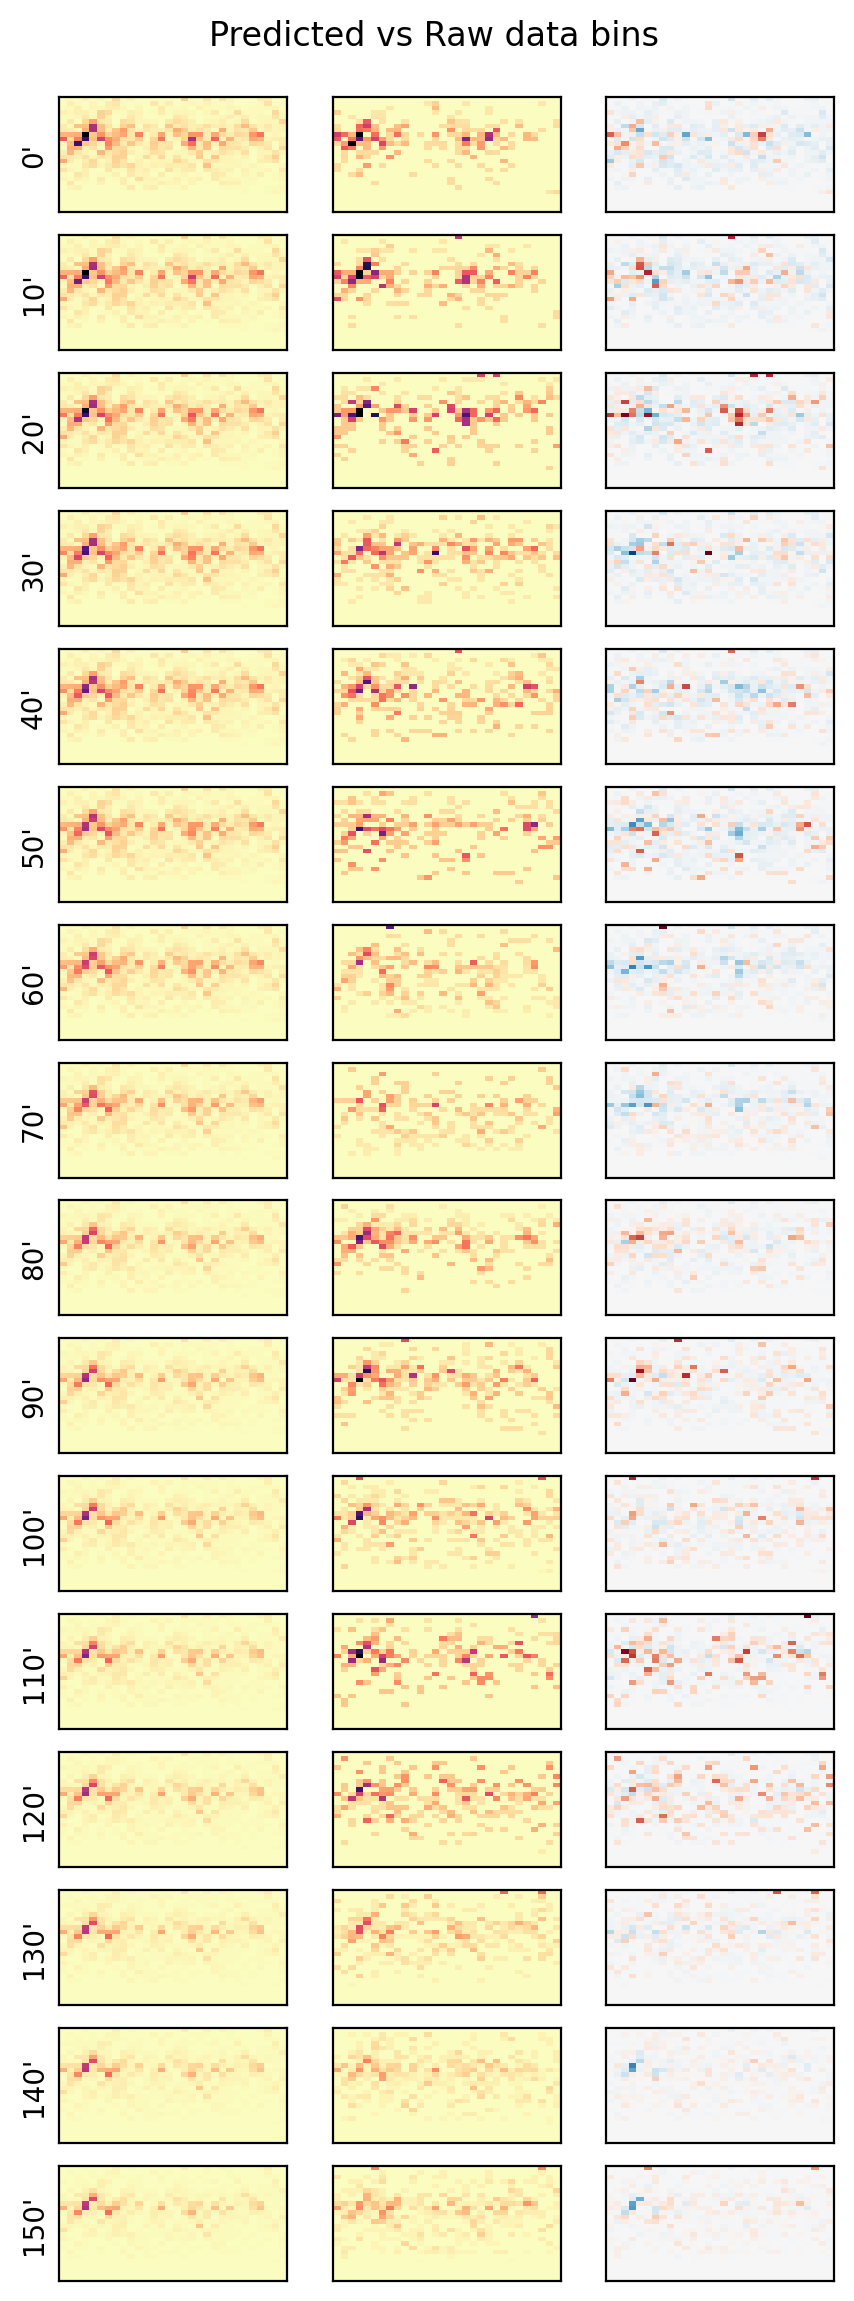

In [632]:


predicted_G = H@F
predicted_G_imgs = predicted_G.reshape((predicted_G.shape[0], 26, -1))
G_imgs = G.reshape((G.shape[0], 26, -1))

num_rows = len(timepoints)
num_cols = 3

fig = plt.figure(figsize=(5, 13))
for i in range(num_rows):

    plt.subplot(num_rows, num_cols, num_cols*i+1)
    plt.imshow(predicted_G_imgs[i], origin='lower', aspect='auto', vmin=0, vmax=0.2,
              cmap='magma_r')
    plt.xticks([])
    plt.yticks([])
    plt.ylabel(f"{timepoints[i]}'")
    
    plt.subplot(num_rows, num_cols, num_cols*i+2)
    plt.imshow(G_imgs[i], origin='lower', aspect='auto', vmin=0, vmax=0.2,
              cmap='magma_r')
    plt.xticks([])
    plt.yticks([])

    plt.subplot(num_rows, num_cols, num_cols*i+3)
    plt.imshow(G_imgs[i]-predicted_G_imgs[i], origin='lower', aspect='auto',
              cmap='RdBu_r', vmin=-0.1, vmax=0.1)
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Predicted vs Raw data bins")
plt.subplots_adjust(top=0.95)